In [21]:
import pandas as pd
from sklearn import tree, linear_model

In [22]:
df = pd.read_csv("data/Dados Comunidade (respostas) - dados.csv")
df.head()

,Carimbo de data/hora,Como conheceu o Téo Me Why?,Quantos cursos acompanhou do Téo Me Why?,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Estado que mora atualmente,Área de Formação,Tempo que atua na área de dados,Posição da cadeira (senioridade),Você se considera uma pessoa feliz?
0,12/06/2025 10:59:27,LinkedIn,0,Sim,Não,Sim,Sim,Sim,Não,34,MG,Exatas,Mais de 4 anos,Sênior,Sim
1,12/06/2025 10:59:34,Twitch,Mais que 3,Sim,Sim,Sim,Não,Não,Sim,26,MG,Exatas,Não atuo,Iniciante,Sim
2,12/06/2025 10:59:36,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Sim,39,SC,Exatas,De 1 ano a 2 anos,Júnior,Sim
3,12/06/2025 10:59:37,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Não,27,SP,Exatas,Mais de 4 anos,Pleno,Sim
4,12/06/2025 10:59:41,Twitch,2,Sim,Sim,Sim,Sim,Não,Não,29,CE,Exatas,De 1 ano a 2 anos,Pleno,Sim


In [23]:
df = df.replace({"Sim":1, "Não":0})
df.head()

,Carimbo de data/hora,Como conheceu o Téo Me Why?,Quantos cursos acompanhou do Téo Me Why?,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Estado que mora atualmente,Área de Formação,Tempo que atua na área de dados,Posição da cadeira (senioridade),Você se considera uma pessoa feliz?
0,12/06/2025 10:59:27,LinkedIn,0,1,0,1,1,1,0,34,MG,Exatas,Mais de 4 anos,Sênior,1
1,12/06/2025 10:59:34,Twitch,Mais que 3,1,1,1,0,0,1,26,MG,Exatas,Não atuo,Iniciante,1
2,12/06/2025 10:59:36,YouTube,Mais que 3,1,1,1,1,1,1,39,SC,Exatas,De 1 ano a 2 anos,Júnior,1
3,12/06/2025 10:59:37,YouTube,Mais que 3,1,1,1,1,1,0,27,SP,Exatas,Mais de 4 anos,Pleno,1
4,12/06/2025 10:59:41,Twitch,2,1,1,1,1,0,0,29,CE,Exatas,De 1 ano a 2 anos,Pleno,1


In [24]:
num_vars = [
    "Curte games?",
    "Curte futebol?",
    "Curte livros?",
    "Curte jogos de tabuleiro?",
    "Curte jogos de fórmula 1?",
    "Curte jogos de MMA?",
    "Idade"
]
dummy_vars =[
    "Como conheceu o Téo Me Why?",
    "Quantos cursos acompanhou do Téo Me Why?",
    "Área de Formação",
    "Tempo que atua na área de dados",
    "Posição da cadeira (senioridade)" 
]

df_analise = pd.get_dummies(df[dummy_vars]).astype(int)
df_analise[num_vars] = df[num_vars].copy()
df_analise['pessoa feliz'] = df['Você se considera uma pessoa feliz?'].copy()
df_analise.head()

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,pessoa feliz
0,0,0,1,0,0,0,0,1,0,0,...,0,1,1,0,1,1,1,0,34,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,0,0,1,26,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,1,1,39,1
3,0,0,0,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,27,1
4,0,0,0,0,1,0,0,0,0,1,...,1,0,1,1,1,1,0,0,29,1


In [25]:
features = df_analise.columns[:-1].tolist()
#print(features)
X = df_analise[features]
y = df_analise['pessoa feliz'].astype(int)
print(y.head())
print('formato de X: ',X.shape)
print('formato de y: ',y.shape)


0    1
1    1
2    1
3    1
4    1
Name: pessoa feliz, dtype: int64
formato de X:  (182, 37)
formato de y:  (182,)


In [26]:


arvore = tree.DecisionTreeClassifier(random_state=42,min_samples_leaf=5)

arvore.fit(X,y)

# reg logistica
reg = linear_model.LogisticRegression(penalty=None, fit_intercept=True)
reg.fit(X,y)

c:\Users\Ivina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ivina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-reg

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [27]:
arvore_predict= arvore.predict(X)
print(arvore_predict)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1
 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 0 0 0 1]


In [28]:
df_predict = df_analise[['pessoa feliz']].copy()
df_predict['predict_arvore'] = arvore_predict


df_predict['proba_arvore'] = arvore.predict_proba(X)[:,1]
print(df_predict)

    pessoa feliz  predict_arvore  proba_arvore
0              1               1      1.000000
1              1               1      0.600000
2              1               1      0.857143
3              1               1      0.857143
4              1               1      1.000000
..           ...             ...           ...
177            1               1      0.800000
178            1               0      0.428571
179            0               0      0.500000
180            0               0      0.500000
181            1               1      1.000000

[182 rows x 3 columns]


In [29]:
# acurácia - porém não é suficiente
(df_predict['pessoa feliz'] == df_predict['predict_arvore']).mean()


np.float64(0.8516483516483516)

In [30]:
# matriz de confusao "na mão"

pd.crosstab(df_predict['pessoa feliz'], df_predict['predict_arvore'])

predict_arvore,0,1
pessoa feliz,,
0,22,13
1,14,133


In [31]:
total_0 = (df_predict['pessoa feliz'] == 0).sum()

total_1 = (df_predict['pessoa feliz'] == 1).sum()
print('total de uns no df: ',total_1,'\ntotal de zeros no df: ',total_0)

print(type(df_predict['pessoa feliz']))
print(type(df_predict['predict_arvore']))

total de uns no df:  147 
total de zeros no df:  35
<class 'pandas.Series'>
<class 'pandas.Series'>


In [32]:
df_predict.to_csv("data/predict.csv", sep=';', index=False)

### Precisão
> Se eu disser que uma pessoa é feliz eu tenho quase [valor_prec] de ser feliz

$precisao = VP/(VP + FP)$

### Acurácia
$acuracia = (VN + VP) / Total$

### Recall ou Sensibilidade
> De todo mundo que é feliz, quantos eu estou dizendo que de fato são felizes? *questões críticas*

$recall = VP / FN + VP$

### Especificidade
> O quanto dos negativos estou capturando -- contrário do recall

$especificidade = VN/(VN+FP)$

### Área sob a Curva ROC (AUC)
> Sensibilidade (recall) x Especificidade

recall = quanto estou capturando da classe 1 

especificidade = quanto estou capturando da classe 0

recall e especificidade em diferentes pontes de corte

- é um gráfico que avalia o desempenho de um modelo de classificação binária ao traçar a relação entre duas métricas em diferentes pontos de corte (thresholds): {recall e especificidade em diferentes pontes de corte}

**Eixo Y** (Sensibilidade ou Recall): Representa a taxa de verdadeiros positivos. Mostra a proporção de casos positivos reais que o modelo conseguiu identificar corretamente.

**Eixo X** (1 - Especificidade): Representa a taxa de falsos positivos. Mostra a proporção de casos negativos que o modelo classificou erroneamente como positivos.


In [33]:
from sklearn import metrics

y_true = df_predict['pessoa feliz'].astype(int)
y_pred = df_predict['predict_arvore'].astype(int)
y_prob = df_predict['proba_arvore']

print("Accuracy:", metrics.accuracy_score(y_true, y_pred))
print("Precision:", metrics.precision_score(y_true, y_pred))
print("Recall:", metrics.recall_score(y_true, y_pred))
print("F1:", metrics.f1_score(y_true, y_pred))
print("ROC AUC:", metrics.roc_auc_score(y_true, y_prob))

Accuracy: 0.8516483516483516
Precision: 0.910958904109589
Recall: 0.9047619047619048
F1: 0.9078498293515358
ROC AUC: 0.9121477162293488


(array([  8.,   9.,   7.,  12.,  20.,   0.,   8.,  10.,   7., 101.]),
 array([0.25 , 0.325, 0.4  , 0.475, 0.55 , 0.625, 0.7  , 0.775, 0.85 ,
        0.925, 1.   ]),
 <BarContainer object of 10 artists>)

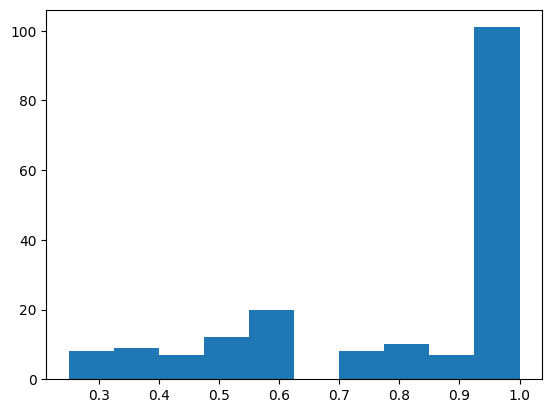

In [34]:
import matplotlib.pyplot as plt
plt.hist(df_predict['proba_arvore'])

In [35]:
pd.Series({"model": reg, "features": features}).to_pickle("model_feliz.pkl")